In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [2]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


torch.manual_seed(42)
np.random.seed(42)

c:\Users\la7tim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
import torchvision
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load CIFAR-10
trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

# Print dataset info
print(f"Training set size: {len(trainset)}")
print(f"Test set size: {len(testset)}")
print(f"Number of classes: {len(trainset.classes)}")

Files already downloaded and verified
Files already downloaded and verified
Training set size: 50000
Test set size: 10000
Number of classes: 100


In [4]:
num_clients = 5
partitions = {
    "dirichlet_iid":      dirichlet_partition(trainset, num_clients=num_clients, alpha=1000.0),  # High alpha -> IID-like
    "dirichlet_noniid":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.01),   # Low alpha -> non-IID
    "dirichlet_medium":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.5),   # Medium skew
}

In [5]:
from models.config import get_tinyprop_config
config = get_tinyprop_config("cifar100")
print("\nModel Configuration:")
for key, value in config.items():
    print(f"{key}: {value}")

# Initialize model parameters
tinyprop_params = config["tinyprop_params"]
print("\nTinyProp Parameters:")
print(f"S_min: {tinyprop_params.S_min}")
print(f"S_max: {tinyprop_params.S_max}")
print(f"zeta: {tinyprop_params.zeta}")
print(f"number_of_layers: {tinyprop_params.number_of_layers}")


Model Configuration:
tinyprop_params: <models.tinyProp.TinyPropParams object at 0x00000280FF62C290>
skip_threshold: 2.5
full_flops_per_batch: 1000000.0
phi_min: 0.2
optimizer: {'type': 'sgd', 'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0005}
lr_scheduler: {'type': 'cosine', 'T_max': 100, 'eta_min': 0.0001, 'warmup_epochs': 5, 'warmup_start_lr': 0.001}
gradient_clip: 1.0
batch_size: 32
num_epochs: 1
label_smoothing: 0.1
data_augmentation: {'random_crop': True, 'random_horizontal_flip': True, 'random_rotation': 5, 'color_jitter': {'brightness': 0.2, 'contrast': 0.2, 'saturation': 0.2}}

TinyProp Parameters:
S_min: 0.05
S_max: 0.5
zeta: 0.25
number_of_layers: 8


In [6]:
from clients.aggregators import sparse_fedavg_aggregate
# First, let's create a function to run training for each partition
def train_and_analyze_partition(partition_name, client_datasets, tinyprop_params):
    print(f"\nTraining on partition: {partition_name.upper()}")
    
    # Run training
    model, accuracy_list, flops_list, mem_list, comm_list, sparsity_list, \
    avg_grad_norm_list, avg_phi_list, skipped_batches_list, \
    effective_compute_ratio_list, client_eval_history, compression_ratio_list, \
    history = federated_training(
        client_datasets=client_datasets,
        model_name='cifar100',
        testset=testset,
        tinyprop_params=tinyprop_params,
        aggregator_fn=sparse_fedavg_aggregate,
        rounds=100,
        device="cuda" if torch.cuda.is_available() else "cpu",
        local_epochs=1,
        early_stopping_patience=100,
        early_stopping_delta=0.001,
        csv_log_path=f'results/cifar100_{partition_name}_training_log.csv',
        initial_sparsity=tinyprop_params.S_min,
        target_sparsity=tinyprop_params.S_max,
        energy_budget=1000
    )
    
    return model, history

partition_results = {}
for strategy_name, client_datasets in partitions.items():
    print(f"\nStarting training for {strategy_name.upper()} partition...")
    try:
        model, history = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
        partition_results[strategy_name] = {
            'model': model,
            'history': history
        }
        print(f"Completed training for {strategy_name.upper()}")
    except Exception as e:
        print(f"Error in {strategy_name.upper()}: {str(e)}")
        continue



Starting training for DIRICHLET_IID partition...

Training on partition: DIRICHLET_IID

Round 1/100

[Client Debug] Starting training for 1 epochs with batch size 32

Epoch 1/1
  - Average Loss: 3.8195
  - Accuracy: 5.26%
  - Smoothed Phi: 0.9117
  - Skipped Batches: 37
  - Current Sparsity: 0.0956
  - Average Gradient Norm: 2.3911
  - Peak Memory: 931.4MB

[Client Debug] Starting training for 1 epochs with batch size 32

Epoch 1/1
  - Average Loss: 4.0649
  - Accuracy: 5.39%
  - Smoothed Phi: 0.9543
  - Skipped Batches: 19
  - Current Sparsity: 0.0814
  - Average Gradient Norm: 2.3787
  - Peak Memory: 963.9MB

[Client Debug] Starting training for 1 epochs with batch size 32

Epoch 1/1
  - Average Loss: 4.1318
  - Accuracy: 5.09%
  - Smoothed Phi: 0.9678
  - Skipped Batches: 14
  - Current Sparsity: 0.0709
  - Average Gradient Norm: 2.3803
  - Peak Memory: 981.5MB

[Client Debug] Starting training for 1 epochs with batch size 32

Epoch 1/1
  - Average Loss: 4.0403
  - Accuracy: 5.30%


Found IID results at results/cifar100_dirichlet_iid_training_log.csv
Found Non-IID results at results/cifar100_dirichlet_noniid_training_log.csv
Found Medium results at results/cifar100_dirichlet_medium_training_log.csv


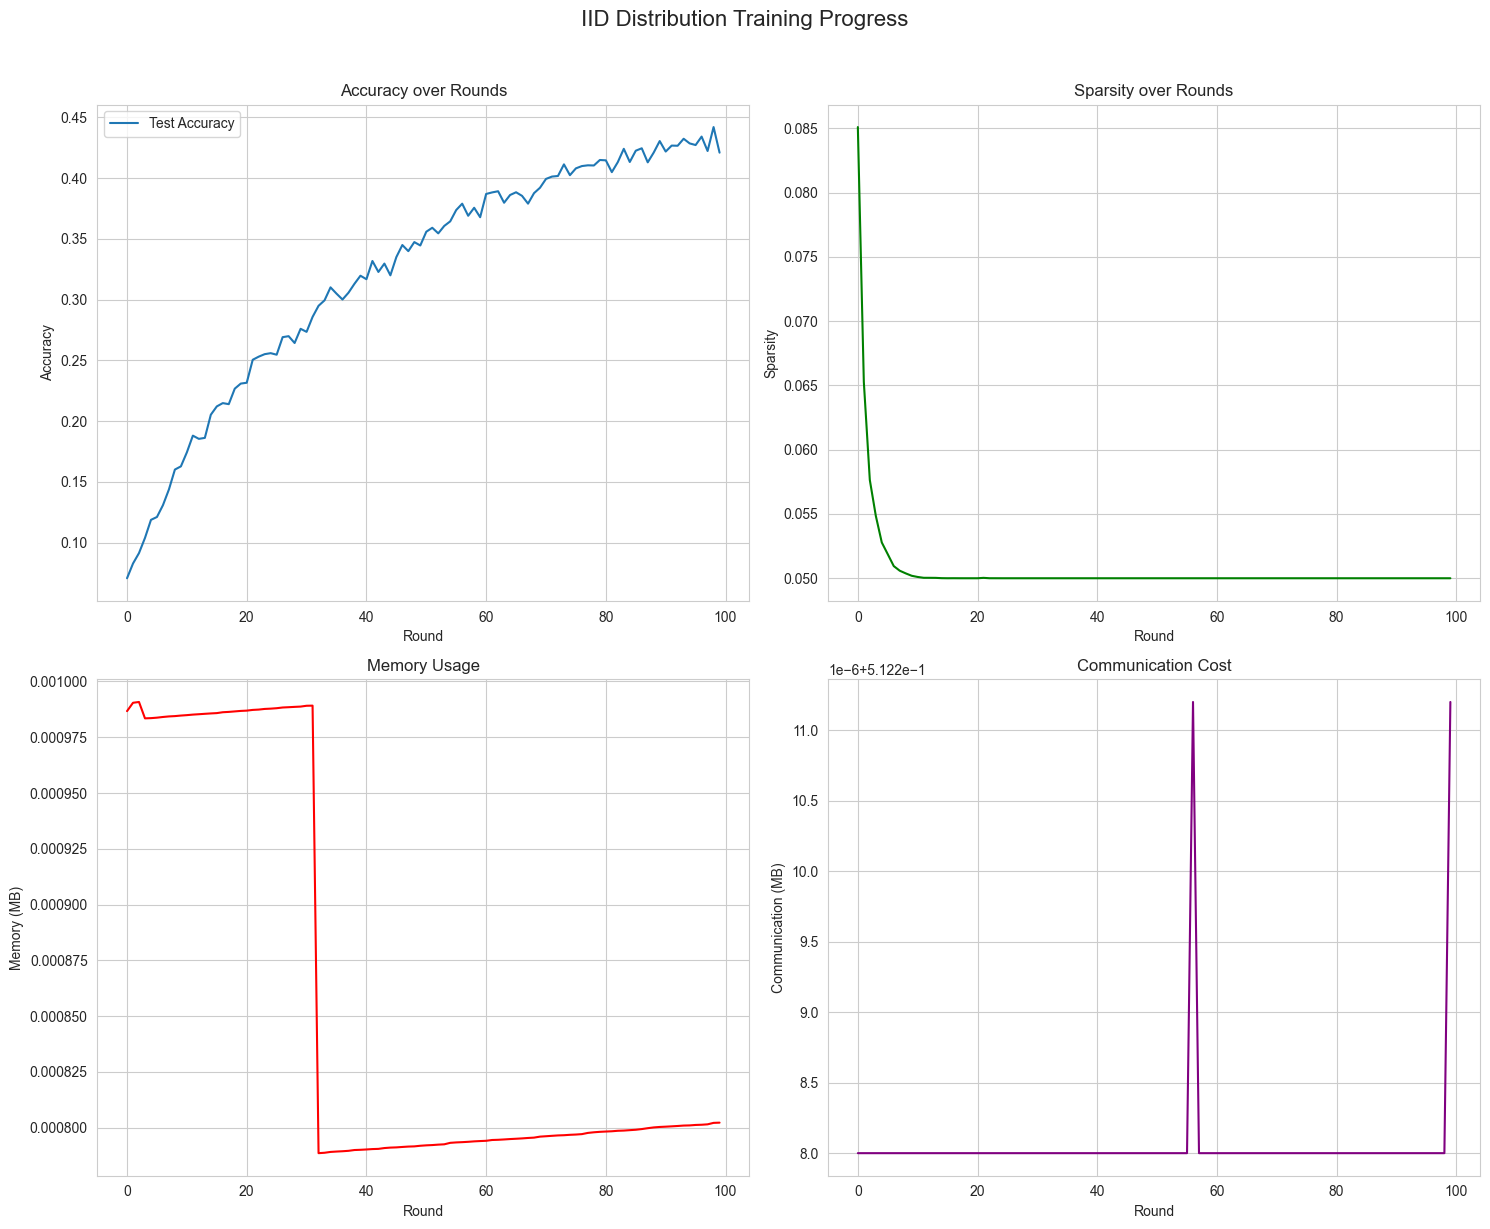

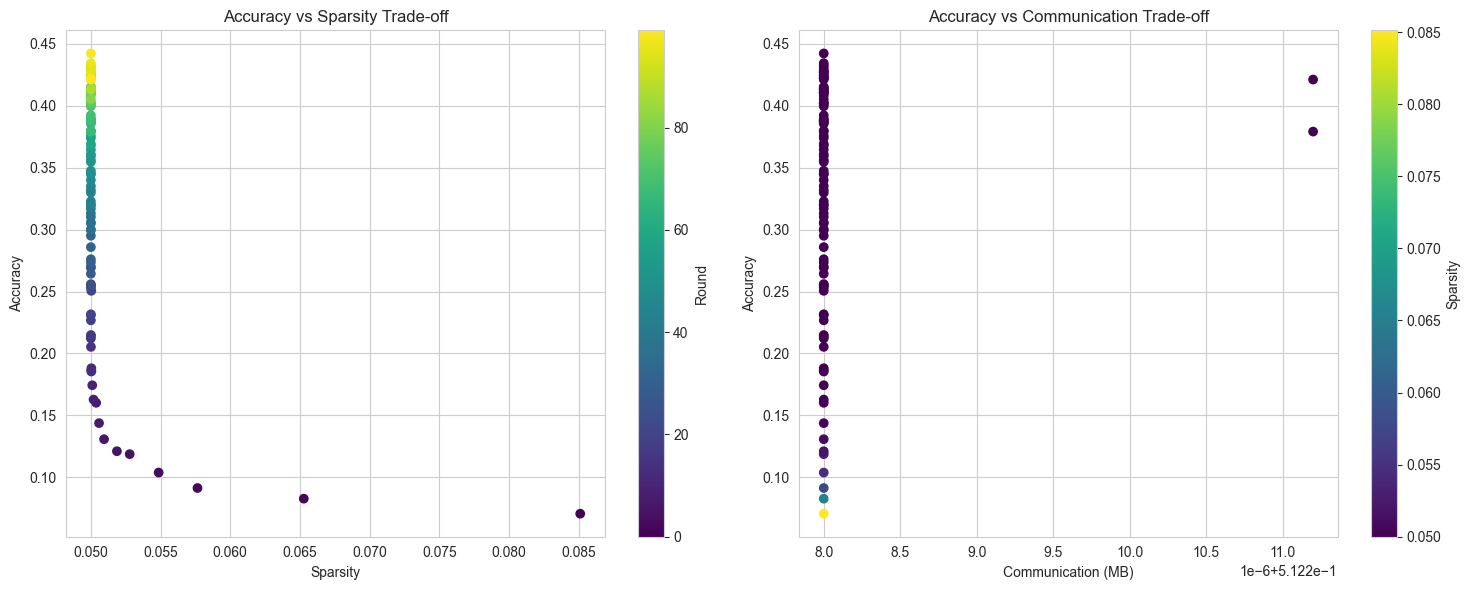

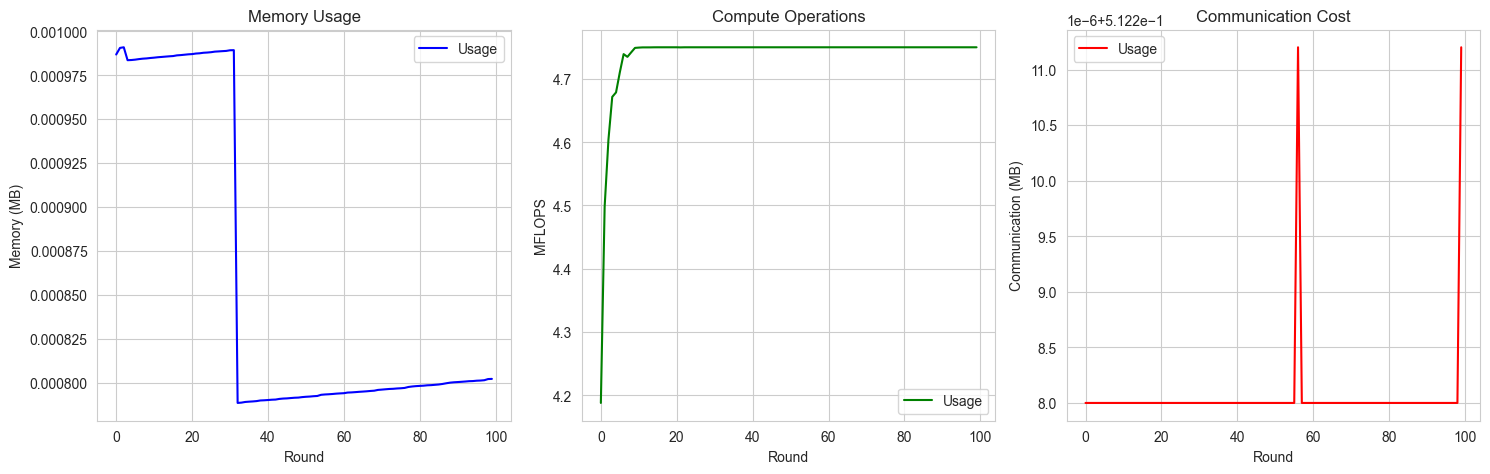

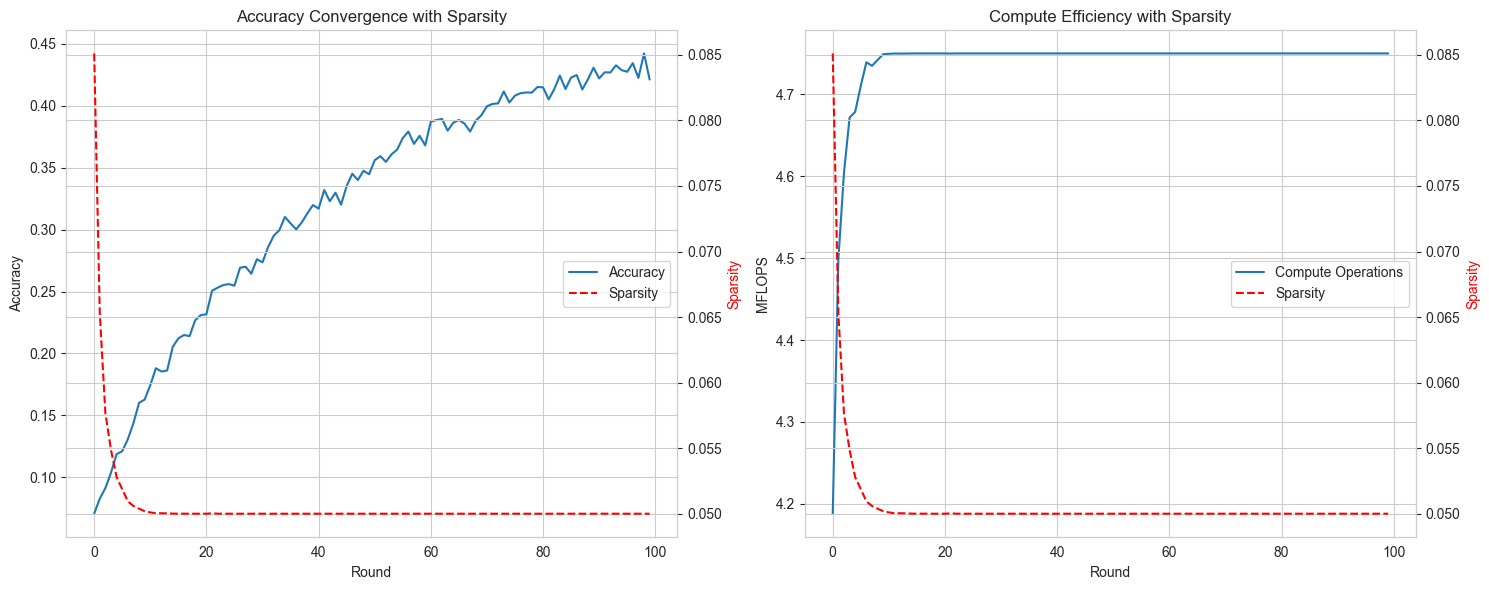

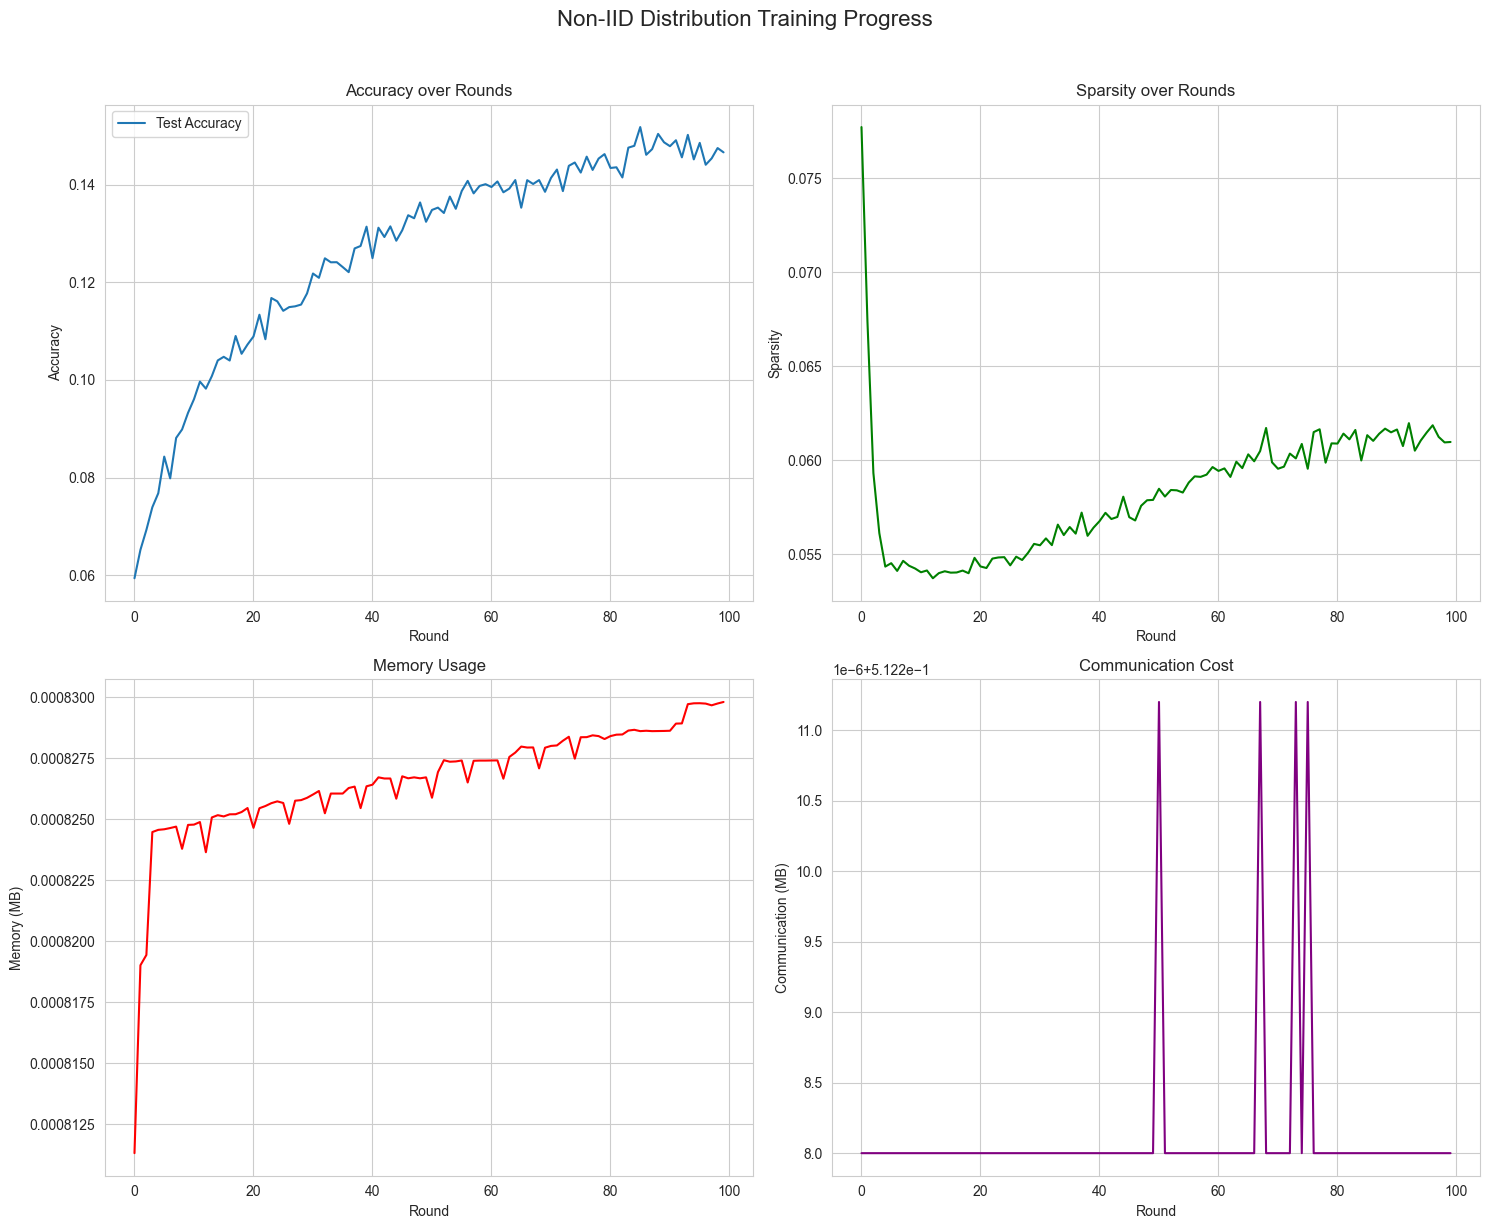

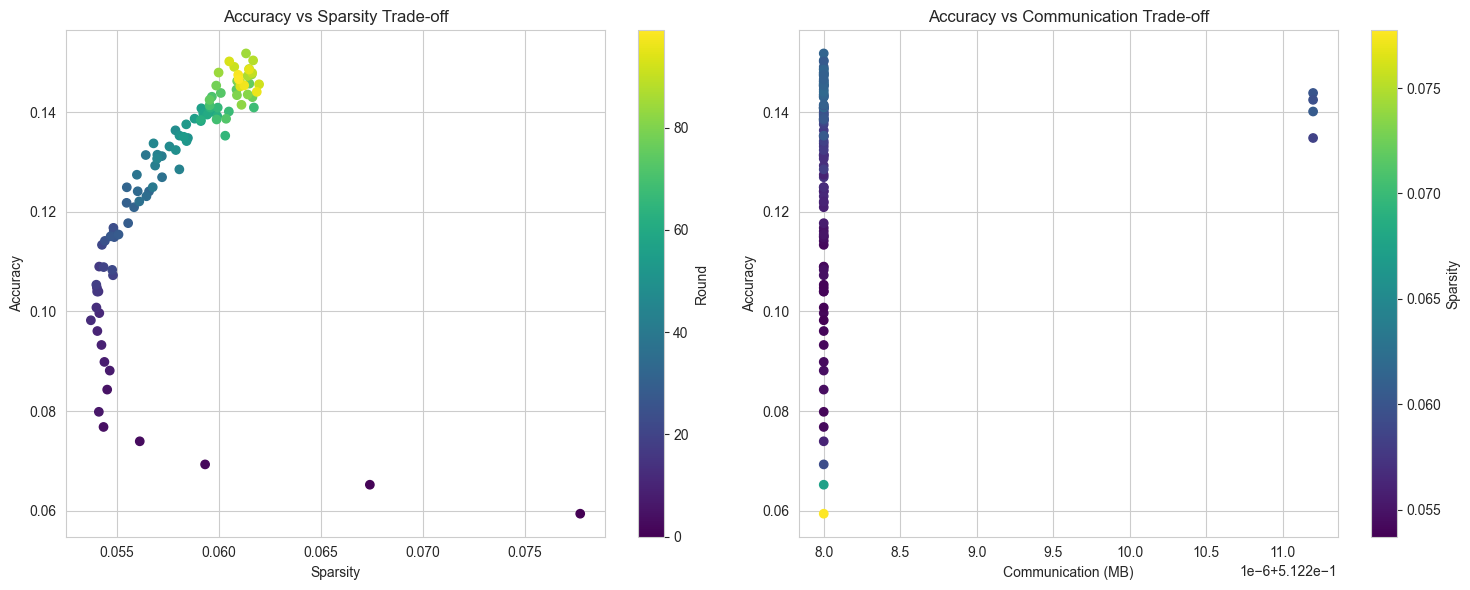

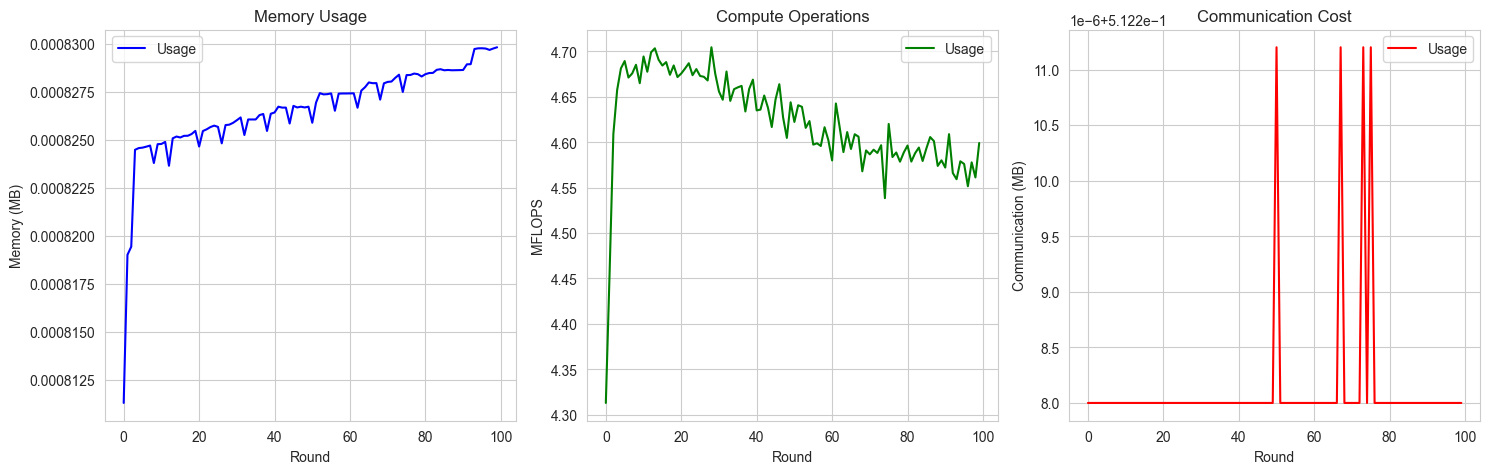

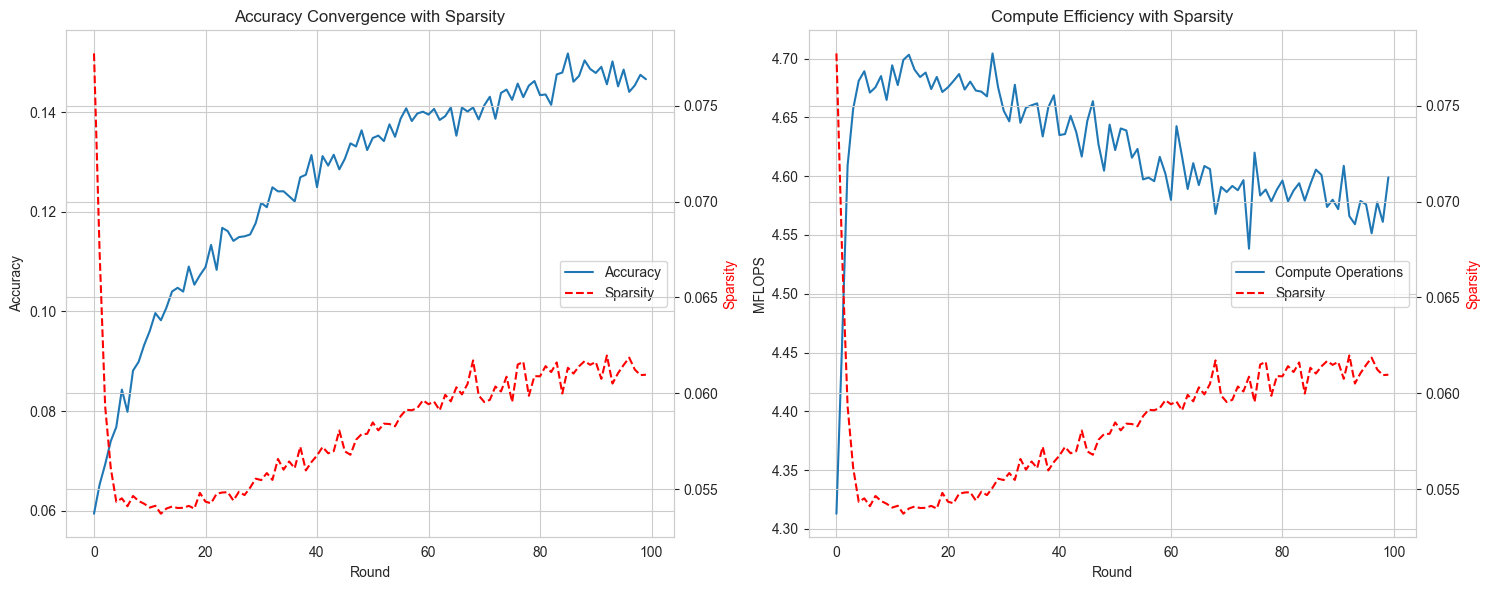

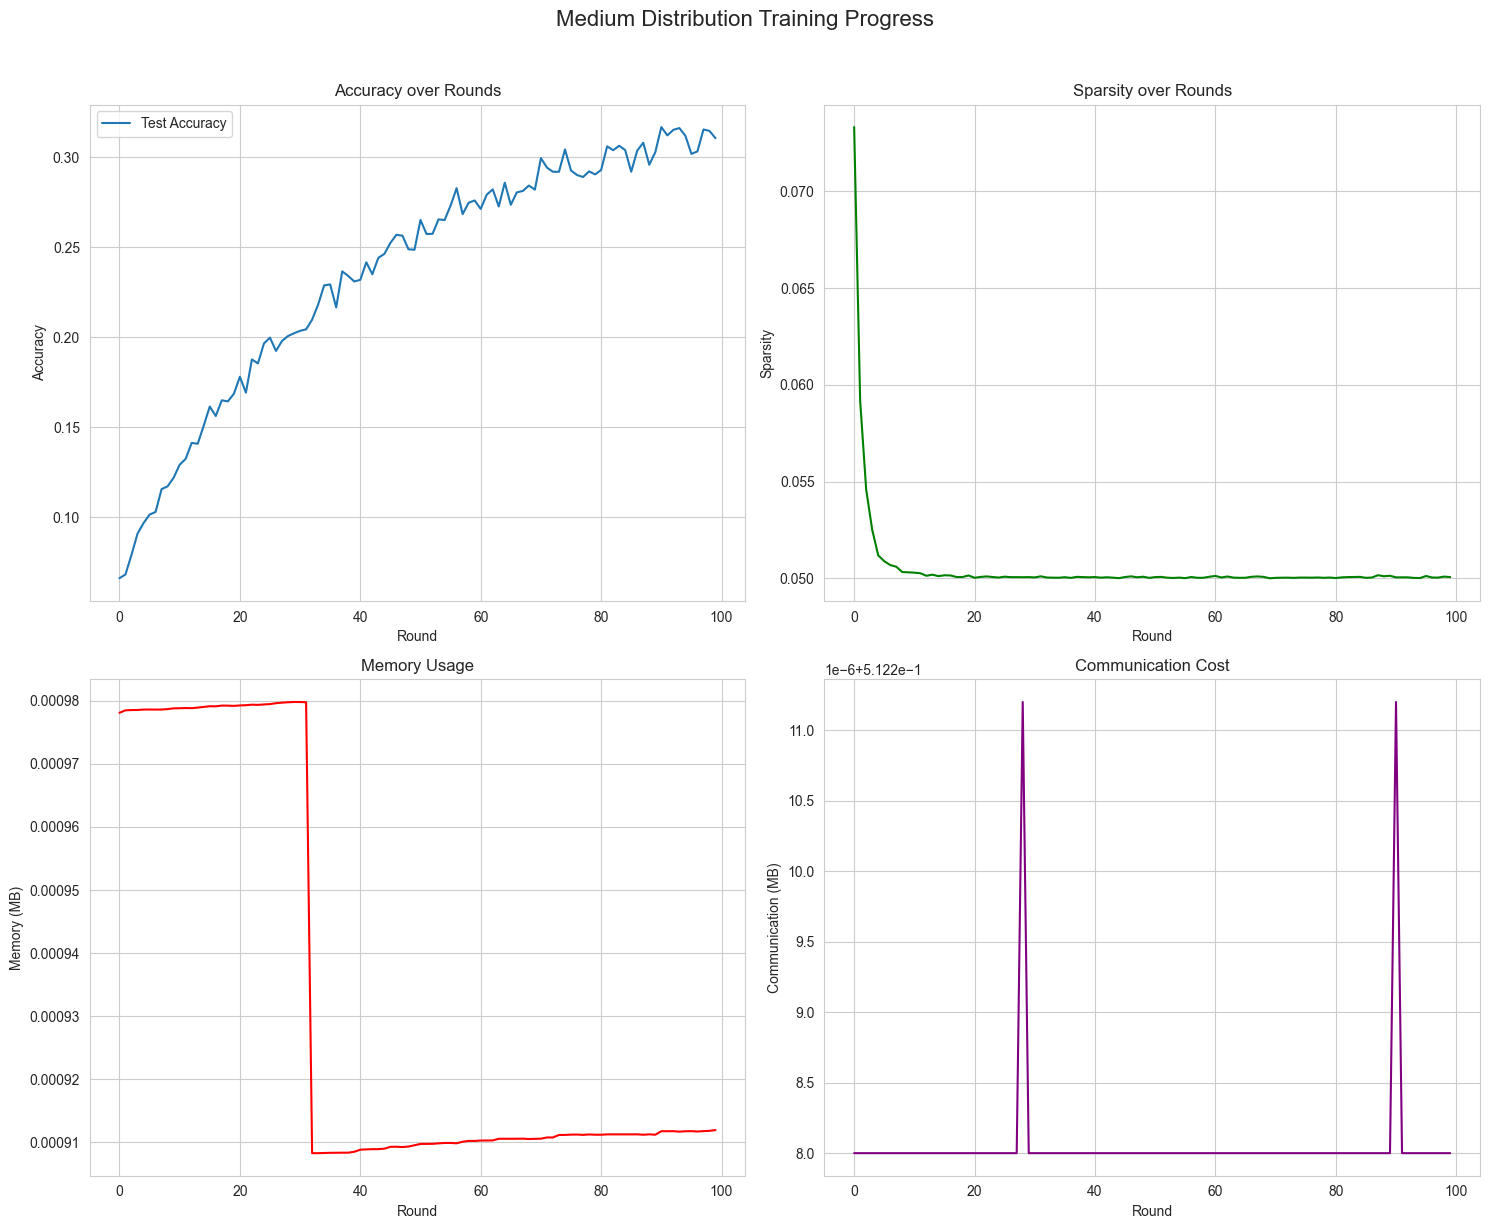

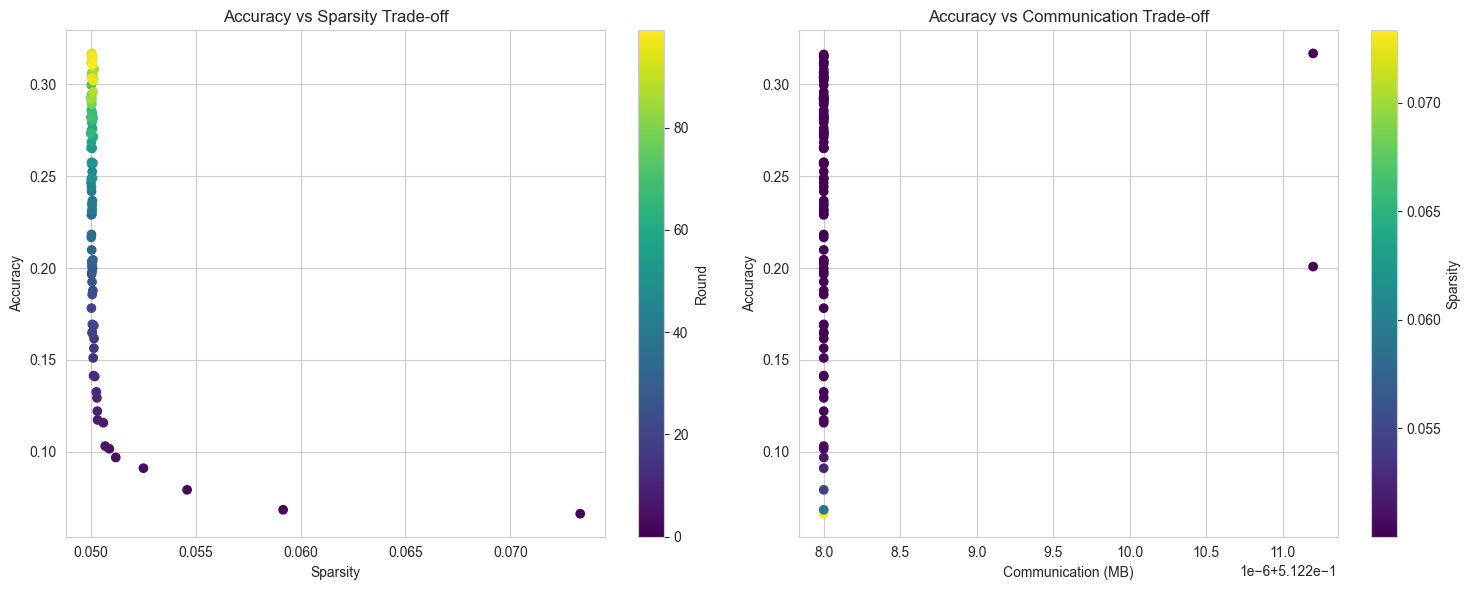

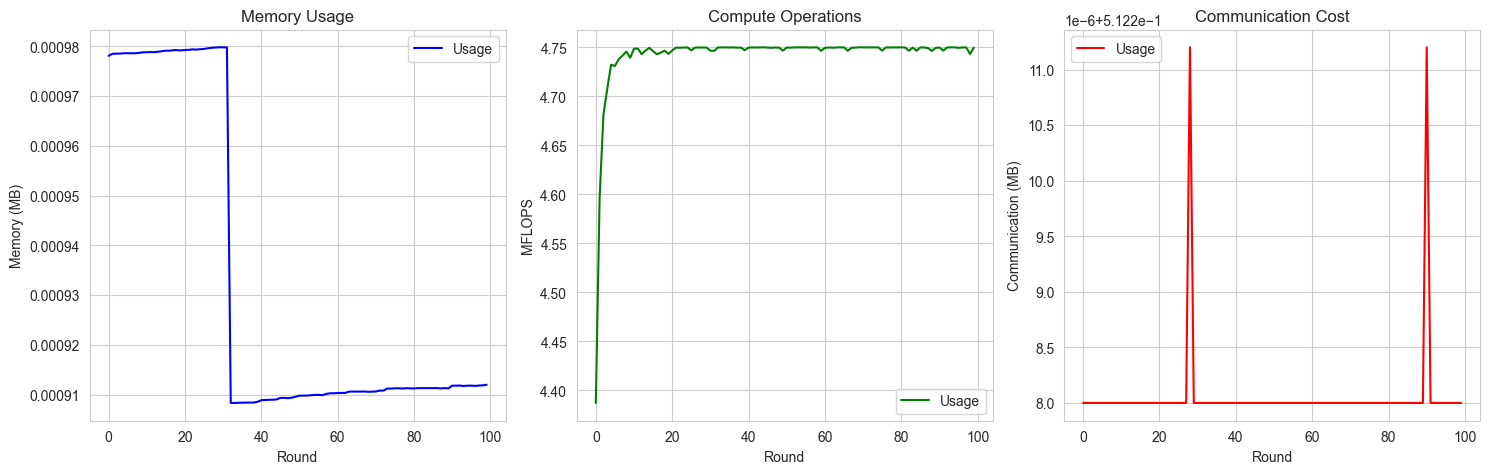

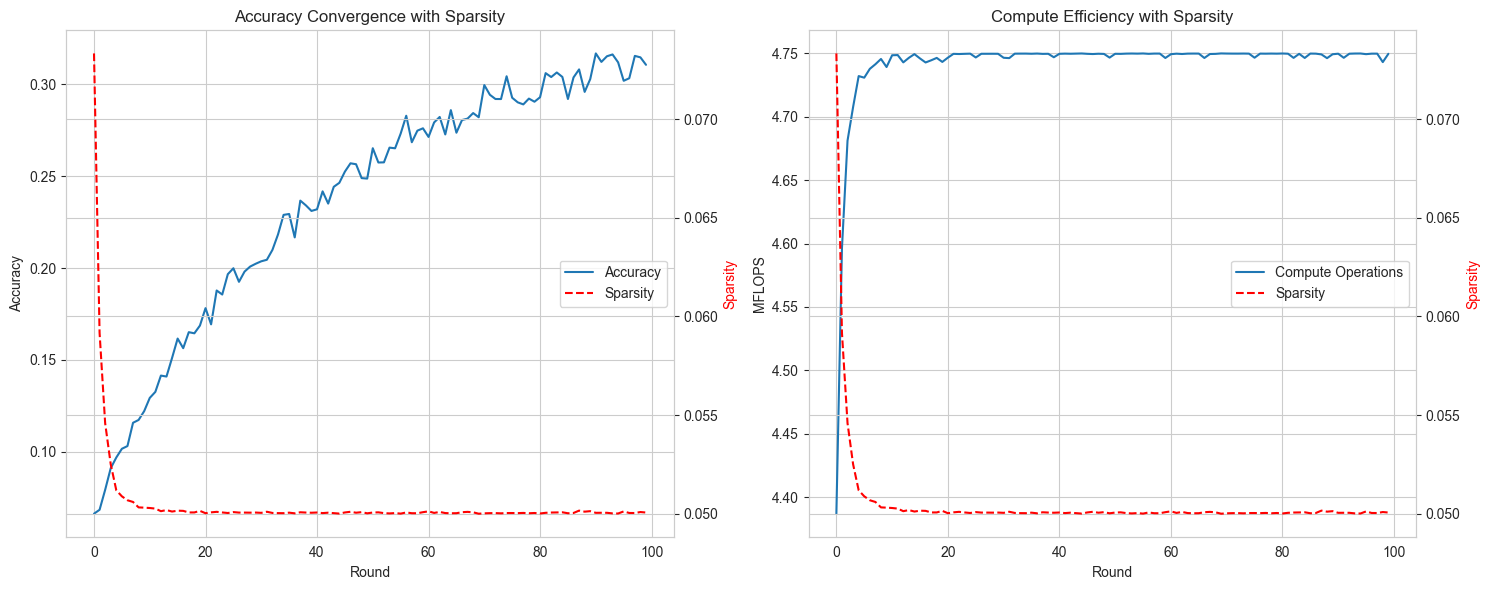


Summary Statistics:
         Final Accuracy  Max Accuracy  Average Memory (MB)  \
IID             0.42100       0.44206             0.000857   
Non-IID         0.14662       0.15180             0.000827   
Medium          0.31070       0.31690             0.000932   

         Average Communication (MB)  Average FLOPS (MFLOPS)  Final Sparsity  \
IID                        0.512208                4.738147        0.050000   
Non-IID                    0.512208                4.623490        0.060968   
Medium                     0.512208                4.741880        0.050067   

         Compression Ratio  Effective Compute Ratio  
IID               1.052632                 1.077519  
Non-IID           1.064927                 1.001336  
Medium            1.052706                 1.028488  


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.visualization import (
    plot_training_metrics,
    plot_efficiency_metrics,
    plot_hardware_profile,
    plot_convergence_analysis
)


csv_paths = {
    'IID': 'results/cifar100_dirichlet_iid_training_log.csv',
    'Non-IID': 'results/cifar100_dirichlet_noniid_training_log.csv',
    'Medium': 'results/cifar100_dirichlet_medium_training_log.csv'
}

for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        print(f"Found {partition} results at {path}")
    except FileNotFoundError:
        print(f"Warning: Could not find {partition} results at {path}")

for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        history = {
            'accuracy': df['accuracy'].values,
            'sparsity': df['sparsity'].values,
            'memory_bytes': df['memory_bytes'].values,
            'communication_bytes': df['communication_bytes'].values,
            'flops': df['flops'].values
        }
        plot_training_metrics(history, title_prefix=f"{partition} Distribution")
        plot_efficiency_metrics(history)
        plot_hardware_profile(history)
        plot_convergence_analysis(history)
    except Exception as e:
        print(f"Error plotting {partition} results: {e}")


summary_stats = {}
for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        summary_stats[partition] = {
            'Final Accuracy': df['accuracy'].iloc[-1],
            'Max Accuracy': df['accuracy'].max(),
            'Average Memory (MB)': df['memory_bytes'].mean() / 1e6,
            'Average Communication (MB)': df['communication_bytes'].mean() / 1e6,
            'Average FLOPS (MFLOPS)': df['flops'].mean() / 1e6,
            'Final Sparsity': df['sparsity'].iloc[-1],
            'Compression Ratio': 1 / (1 - df['sparsity'].iloc[-1]),
            'Effective Compute Ratio': (1 - df['sparsity'].iloc[-1]) * df['flops'].iloc[-1] / df['flops'].iloc[0]
        }
    except Exception as e:
        print(f"Error calculating statistics for {partition}: {e}")

summary_df = pd.DataFrame(summary_stats).T
print("\nSummary Statistics:")
print(summary_df)